In [56]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple
import json
import numpy as np
import xmltodict


def load_data_and_calibration(npz_path: str | Path, xml_path: str | Path) -> tuple[np.ndarray, float, float]:
    """
    Load spectrum data + parse dispersion/offset from AutoScript metadata XML.
    Returns (data, dispersion, offset).
    """
    npz_path = Path(npz_path)
    xml_path = Path(xml_path)

    # --- load data ---
    # data = np.load(npz_path)["data"]
    
    ## npy load
    data = np.load(npz_path)
    print(data.shape)

    # --- load + parse XML ---
    xml_string = xml_path.read_text(encoding="utf-8")
    metadata = xmltodict.parse(xml_string)
    metadata = json.loads(json.dumps(metadata))  # normalize to plain dict

    detectors = metadata["Metadata"]["Detectors"]["AnalyticalDetector"]
    if isinstance(detectors, dict):
        detectors = [detectors]

    det = detectors[0]  # or filter by Name later if needed
    dispersion = float(det.get("Dispersion", 0))
    offset = float(det.get("OffsetEnergy", 0))

    return data, dispersion, offset

In [57]:
# import sidpy
# import numpy as np


# def sidpy_spectrum_from_disk(npz_path: str | Path, xml_path: str | Path, dispersion_constant = 1.003) -> sidpy.Dataset:
#     """
#     Read saved spectrum + XML, build a sidpy.Dataset with Energy axis in eV.
#     """
#     data, dispersion, offset = load_data_and_calibration(npz_path, xml_path)

#     # --- energy axis ---
#     energy = np.arange(data.shape[0], dtype=float) * dispersion*dispersion_constant + offset

#     # --- sidpy dataset ---
#     ds = sidpy.Dataset.from_array(data)
#     ds.data_type = "spectrum"
#     ds.quantity = "Intensity"
#     ds.units = "counts"

#     ds.set_dimension(0, sidpy.Dimension(energy, name="Energy", units="eV", quantity="Energy",dimension_type='spectral'
# ))

#     # (optional) keep raw XML around
#     ds.metadata = {"autoscript_xml_path": str(xml_path), "dispersion": dispersion, "offset": offset}

#     return ds

In [58]:
import sidpy
import numpy as np


def sidpy_spectrum_from_disk(spectrum, dispersion_constant = 1.003) -> sidpy.Dataset:
    """
    Read saved spectrum + XML, build a sidpy.Dataset with Energy axis in eV.
    """

    dispersion = 10
    offset = -250
    # --- energy axis ---
    energy = np.arange(spectrum.shape[0], dtype=float) * dispersion*dispersion_constant + offset

    # --- sidpy dataset ---
    ds = sidpy.Dataset.from_array(spectrum)
    ds.data_type = "spectrum"
    ds.quantity = "Intensity"
    ds.units = "counts"

    ds.set_dimension(0, sidpy.Dimension(energy, name="Energy", units="eV", quantity="Energy",dimension_type='spectral'
))

    # (optional) keep raw XML around
    # ds.metadata = {"autoscript_xml_path": str(xml_path), "dispersion": dispersion, "offset": offset}

    return ds

In [59]:
import numpy as np

def load_edx_datasets(npy_path, dispersion_constant=1.003):
    spectra = np.load(npy_path)   # shape (N, 4096)
    print(spectra.shape)
    print(spectra.shape)
    datasets = []

    for i in range(spectra.shape[0]):
        spectrum = spectra[i]
        ds = sidpy_spectrum_from_disk(
            spectrum,              # pass 1D array
            dispersion_constant=dispersion_constant
        )
        datasets.append(ds)

    return datasets

In [60]:
npy_path = "/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/notebooks/multimodal-data-process/20260228_114447_stem_edx_1772297087/raw_spectra.npy"

# xml_path = "/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/notebooks/spectrum_related/my_run/eds_0001.xml"

ds_list = load_edx_datasets(npy_path)

print(len(ds_list))


(10, 4096)
(10, 4096)
10


In [ ]:
# ds = sidpy_spectrum_from_disk("my_run/eds_0001.npz", "my_run/eds_0001.xml", dispersion_constant = 1.003)
# print(ds)

sidpy.Dataset of type SPECTRUM with:
 dask.array<array, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
 data contains: Intensity (counts)
 and Dimensions: 
Energy:  Energy (eV) of size (4096,)
 with metadata: ['autoscript_xml_path', 'dispersion', 'offset']


In [32]:
# ##### set more metadata about detector - I dont get it but 
# ### Does not work for spectrum images
# # 

# import pyTEMlib
# spectrum = ds
# start = np.searchsorted(spectrum.Energy.values, 100)
# energy_scale = spectrum.Energy.values[start:]
# spectrum.metadata.setdefault('EDS', {})
# spectrum.metadata['EDS'].setdefault('detector', {})
# spectrum.metadata['EDS']['detector'] = {'layers': {13: {'thickness': 5e-08, 'Z': 13, 'element': 'Al'}},
#  'SiDeadThickness': 1.3e-07,
#  'SiLiveThickness': 0.05,
#  'detector_area': 2.9999999999999997e-05,
#  'energy_resolution': 125,
#  'start_energy': 120,
#  'start_channel': 100,
#  'ElevationAngle': 0.31415927,
#  'AzimuthAngle': 3.9269908169872414,
#  'RealTime': 26.2338126,
#  'LiveTime': 25.20496870466589}

# detector_Efficiency= pyTEMlib.eds_tools.detector_response(spectrum)  # tags, spectrum.energy_scale.values[start:])


# spectrum.metadata['EDS']['detector'].setdefault('start_energy',  120)
# spectrum.metadata['EDS']['detector']['start_channel'] = np.searchsorted(spectrum.Energy.values, spectrum.metadata['EDS']['detector']['start_energy'])
# start = spectrum.metadata['EDS']['detector']['start_channel']
# spectrum[:spectrum.metadata['EDS']['detector']['start_channel']] = 100.

# spectrum.metadata['EDS']['detector']['detector_efficiency']  = detector_Efficiency

import numpy as np
import pyTEMlib

DETECTOR_META = {
    "layers": {13: {"thickness": 5e-08, "Z": 13, "element": "Al"}},
    "SiDeadThickness": 1.3e-07,
    "SiLiveThickness": 0.05,
    "detector_area": 3.0e-05,
    "energy_resolution": 125,
    "start_energy": 120,
    "ElevationAngle": 0.31415927,
    "AzimuthAngle": 3.9269908169872414,
    "RealTime": 26.2338126,
    "LiveTime": 25.20496870466589,
}

def attach_detector_metadata(ds, detector_meta=DETECTOR_META, clip_value=100.0, start_energy_key="start_energy"):
    # ensure dict structure
    ds.metadata.setdefault("EDS", {})
    ds.metadata["EDS"].setdefault("detector", {})

    # set detector meta (overwrite with provided)
    ds.metadata["EDS"]["detector"].update(detector_meta)

    # compute start channel from energy axis
    start_energy = ds.metadata["EDS"]["detector"].get(start_energy_key, 120)
    start_channel = int(np.searchsorted(ds.Energy.values, start_energy))
    ds.metadata["EDS"]["detector"]["start_channel"] = start_channel

    # compute efficiency + store
    det_eff = pyTEMlib.eds_tools.detector_response(ds)
    ds.metadata["EDS"]["detector"]["detector_efficiency"] = det_eff

    # optionally clip low-energy region
    if clip_value is not None and start_channel > 0:
        ds[:start_channel] = clip_value

    return ds

def attach_detector_metadata_many(ds_list, **kwargs):
    return [attach_detector_metadata(ds, **kwargs) for ds in ds_list]

In [33]:
ds_list = attach_detector_metadata_many(ds_list)

In [34]:
ds_list

[sidpy.Dataset of type SPECTRUM with:
  dask.array<setitem, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
  data contains: Intensity (counts)
  and Dimensions: 
 Energy:  Energy (eV) of size (4096,)
  with metadata: ['EDS'],
 sidpy.Dataset of type SPECTRUM with:
  dask.array<setitem, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
  data contains: Intensity (counts)
  and Dimensions: 
 Energy:  Energy (eV) of size (4096,)
  with metadata: ['EDS'],
 sidpy.Dataset of type SPECTRUM with:
  dask.array<setitem, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
  data contains: Intensity (counts)
  and Dimensions: 
 Energy:  Energy (eV) of size (4096,)
  with metadata: ['EDS'],
 sidpy.Dataset of type SPECTRUM with:
  dask.array<setitem, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
  data contains: Intensity (counts)
  and Dimensions: 
 Energy:  Energy (eV) of size (4096,)
  with metadata: [

In [35]:
# # FInd elements
# # --------Input -----------
# minimum_number_of_peaks = 10
# # --------------------------
%matplotlib inline
# import sys
# import numpy as np
# import matplotlib.pylab as plt

# elements = pyTEMlib.eds_tools.get_elements(spectrum, minimum_number_of_peaks, verbose=False)

# plt.figure()
# plt.plot(spectrum.Energy,spectrum, label = 'spectrum')
# pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
# plt.legend();
# plt.xlim(0,19000)
# elements
import matplotlib.pyplot as plt
import pyTEMlib

def plot_edx_spectra(ds_list, minimum_number_of_peaks=10):
    for i, spectrum in enumerate(ds_list):
        elements = pyTEMlib.eds_tools.get_elements(
            spectrum, minimum_number_of_peaks, verbose=False
        )

        plt.figure()
        plt.plot(spectrum.Energy, spectrum, label="spectrum")
        pyTEMlib.eds_tools.plot_lines(
            spectrum.metadata["EDS"], plt.gca()
        )

        plt.legend()
        plt.xlim(0, 19000)
        plt.title(f"Spectrum {i} | Elements: {elements}")
        plt.show()

/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/.venv/lib/python3.11/site-packages/dask/array/core.py:1738: FutureWarning: The `numpy.argsort` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


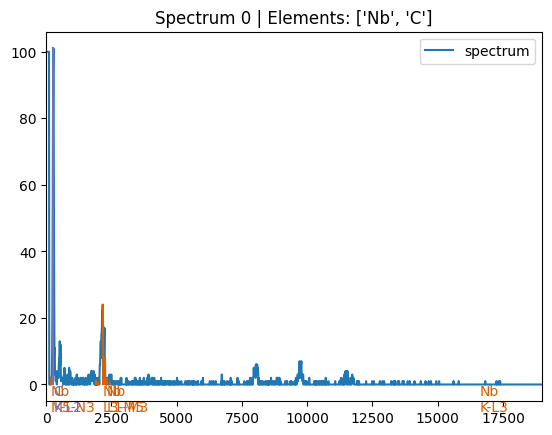

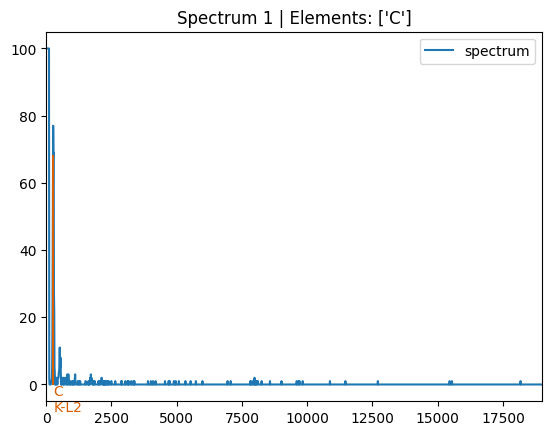

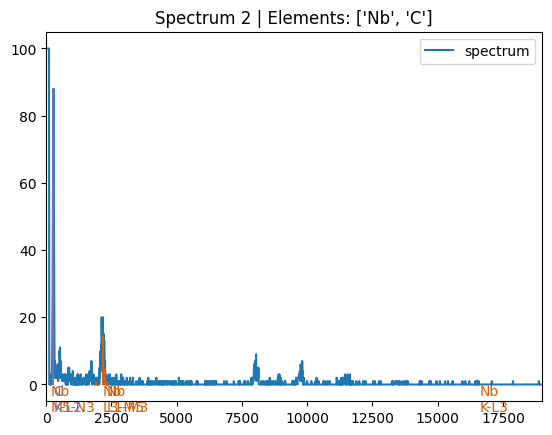

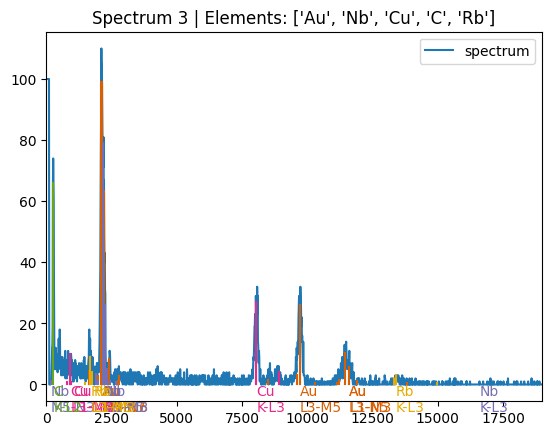

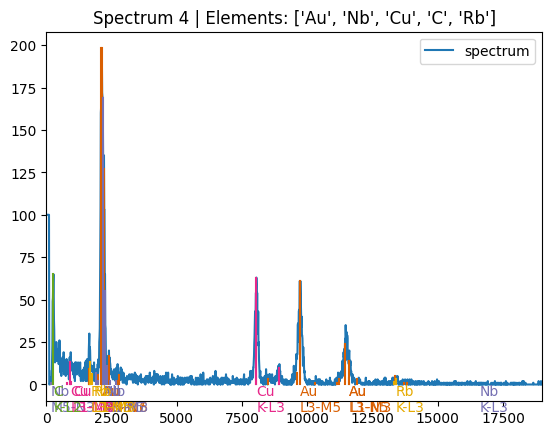

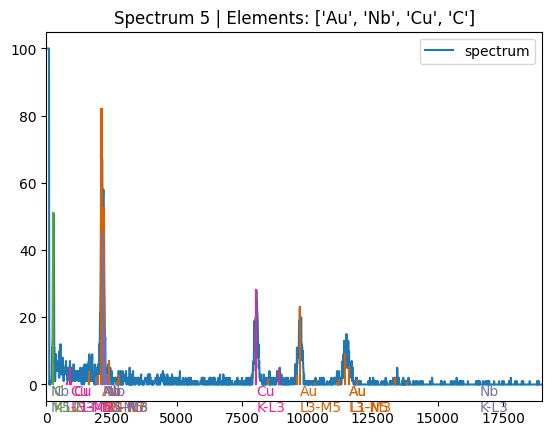

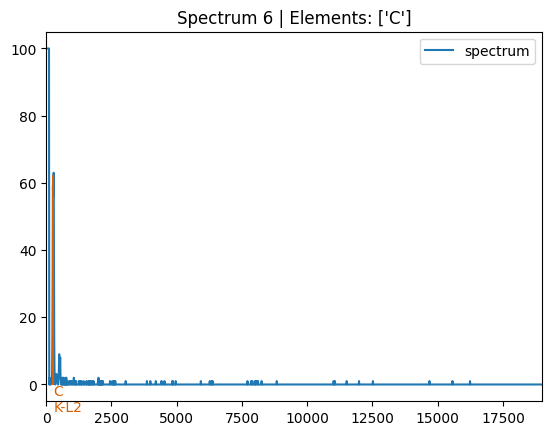

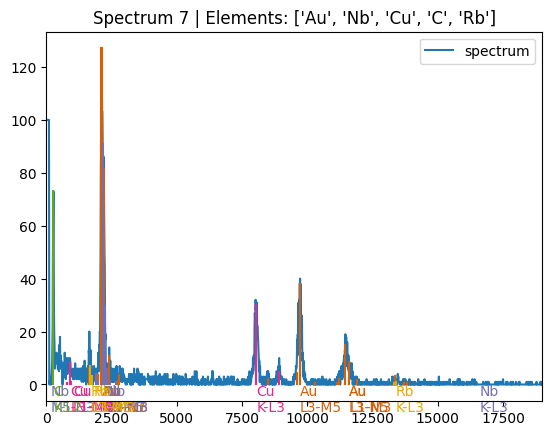

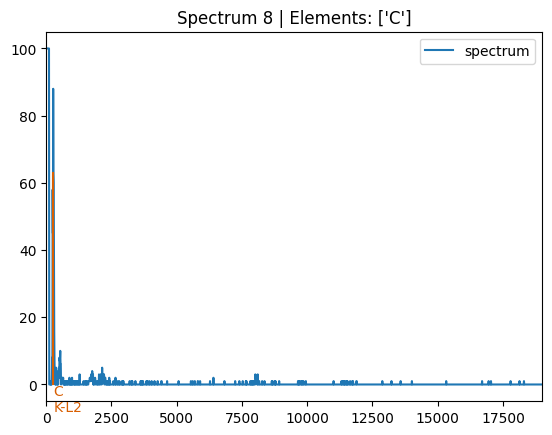

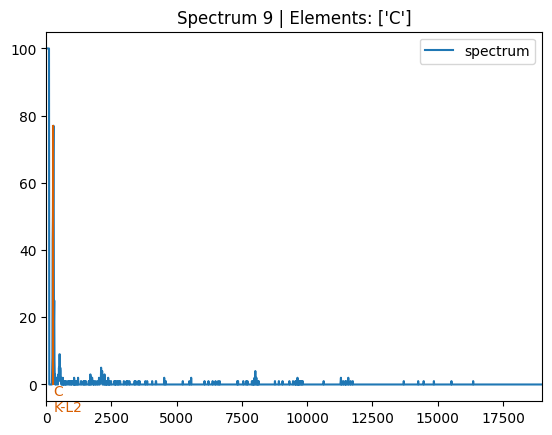

In [36]:
plot_edx_spectra(ds_list)

In [43]:
# ## Add Mg
# def add_element(spectrum, elements):
#     if isinstance(elements, str):
#         elements = [elements]
#     if not isinstance(elements, list):
#         raise ValueError("elements must be a string or a list of strings")
#     spectrum.metadata['EDS'].update(pyTEMlib.eds_tools.get_x_ray_lines(spectrum, elements))

# add_element(spectrum, ['Fe','Ni', 'Cr'])   
import pyTEMlib

def add_elements(ds, elements):
    if isinstance(elements, str):
        elements = [elements]
    if not isinstance(elements, list):
        raise ValueError("elements must be a string or list[str]")

    ds.metadata.setdefault("EDS", {})
    ds.metadata["EDS"].update(pyTEMlib.eds_tools.get_x_ray_lines(ds, elements))
    return ds

def add_elements_many(ds_list, elements):
    return [add_elements(ds, elements) for ds in ds_list]

ds_list = add_elements_many(ds_list, ["Au", "Ni", "Cr"])  # add Mg too if you want: ["Fe","Ni","Cr","Mg"]


In [45]:
# # quantify 
# peaks, pp = pyTEMlib.eds_tools.fit_model(spectrum, use_detector_efficiency=True)
# q_dict = pyTEMlib.eds_tools.load_k_factors()

# import io
# import contextlib

# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     pyTEMlib.eds_tools.quantify_eds(spectrum, q_dict, mask=['C','F','Ne'])

# output = f.getvalue()
# print(output)
# results = {}

# for line in output.splitlines():
#     if ":" in line and "at%" in line:
#         element, rest = line.split(":")
#         parts = rest.strip().split()
#         at = float(parts[0])
#         wt = float(parts[2])
#         results[element.strip()] = {"at%": at, "wt%": wt}

# print(results)
import io
import contextlib
import pyTEMlib

def quantify_one(ds, q_dict=None, mask=("C", "F", "Ne"), use_detector_efficiency=True):
    if q_dict is None:
        q_dict = pyTEMlib.eds_tools.load_k_factors()

    # fit model (optional but you had it)
    pyTEMlib.eds_tools.fit_model(ds, use_detector_efficiency=use_detector_efficiency)

    # capture printed quantify output -> dict
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        pyTEMlib.eds_tools.quantify_eds(ds, q_dict, mask=list(mask))

    results = {}
    for line in buf.getvalue().splitlines():
        if ":" in line and "at%" in line:
            element, rest = line.split(":", 1)
            parts = rest.strip().split()
            results[element.strip()] = {"at%": float(parts[0]), "wt%": float(parts[2])}

    return results

def quantify_many(ds_list, q_dict=None, mask=("C", "F", "Ne"), use_detector_efficiency=True):
    if q_dict is None:
        q_dict = pyTEMlib.eds_tools.load_k_factors()
    return [
        quantify_one(ds, q_dict=q_dict, mask=mask, use_detector_efficiency=use_detector_efficiency)
        for ds in ds_list
    ]

In [46]:
results_list = quantify_many(ds_list)   # list[dict] (one dict per spectrum)
print(results_list[0])

{'Nb': {'at%': -27.57, 'wt%': -10.33}, 'Au': {'at%': 143.56, 'wt%': 113.99}, 'Ni': {'at%': -11.62, 'wt%': -2.75}, 'Cr': {'at%': -4.36, 'wt%': -0.91}}


In [62]:
import numpy as np
import matplotlib.pyplot as plt

def plot_edx_overlays_pretty(
    haadf,
    centroid_pixel_pos,
    results_list,
    metrics=("at%", "wt%"),
    n_cols=4,
    cmap="magma",
    clamp_to_0_100=True,
    clip_percentiles=(2, 98),
    point_size=60,
    point_alpha=0.9,
    edgecolor="white",
    linewidth=0.8,
):
    # align lengths
    N = min(len(results_list), len(centroid_pixel_pos))
    pos = np.asarray(centroid_pixel_pos)[:N]
    results_list = results_list[:N]
    xs, ys = pos[:, 0], pos[:, 1]

    # elements seen anywhere
    elements = sorted({el for r in results_list for el in r.keys()})
    panels = [(el, m) for el in elements for m in metrics]

    n_panels = len(panels)
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.6 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for k, (el, m) in enumerate(panels):
        ax = axes[k]
        ax.imshow(haadf, cmap="gray", interpolation="nearest")
        ax.set_axis_off()

        vals = np.array([r.get(el, {}).get(m, np.nan) for r in results_list], dtype=float)

        if clamp_to_0_100:
            vals = np.clip(vals, 0, 100)

        finite = vals[np.isfinite(vals)]
        if finite.size:
            vmin, vmax = np.percentile(finite, clip_percentiles)
            if np.isclose(vmin, vmax):  # avoid degenerate colorbar
                vmin, vmax = finite.min(), finite.max()
        else:
            vmin = vmax = None

        sc = ax.scatter(
            xs, ys,
            c=vals,
            s=point_size,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=point_alpha,
            edgecolors=edgecolor,
            linewidths=linewidth,
        )

        ax.set_title(f"{el} {m}", fontsize=12)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
        cbar.ax.tick_params(labelsize=9)

    # hide unused
    for j in range(n_panels, n_rows * n_cols):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()

Found HAADF file: /nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/notebooks/multimodal-data-process/20260228_114447_stem_edx_1772297087/HAADF_image_20260228_114447.tiff


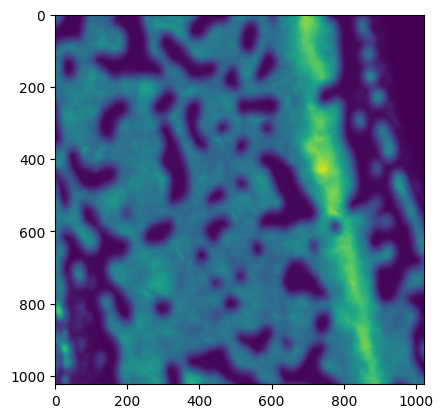

In [48]:
import numpy as np
import os

folder_path = "/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/notebooks/multimodal-data-process/20260228_114447_stem_edx_1772297087"

# Find all .tiff files that contain 'haadf' in their name (case-insensitive)
haadf_files = [
    f for f in os.listdir(folder_path)
    if f.lower().endswith(".tiff") and "haadf" in f.lower()
]

# Ensure there’s exactly one match
if len(haadf_files) == 1:
    file_name = os.path.join(folder_path, haadf_files[0])
    print("Found HAADF file:", file_name)
elif len(haadf_files) == 0:
    raise FileNotFoundError("No HAADF .tiff file found in folder.")
else:
    file_name = os.path.join(folder_path, haadf_files[-1])
    raise ValueError(f"Multiple HAADF .tiff files found: {haadf_files}")

import tifffile
import matplotlib.pyplot as plt
with tifffile.TiffFile(file_name) as tif:
    haadf = tif.asarray()
    
plt.imshow(haadf)

pixel_pos = np.load(folder_path + "/" + "pixel_pos.npy")
spectra_norm = np.load(folder_path + "/" + "normalized_spectra.npy")

In [55]:
pixel_pos.shape

(52, 2)

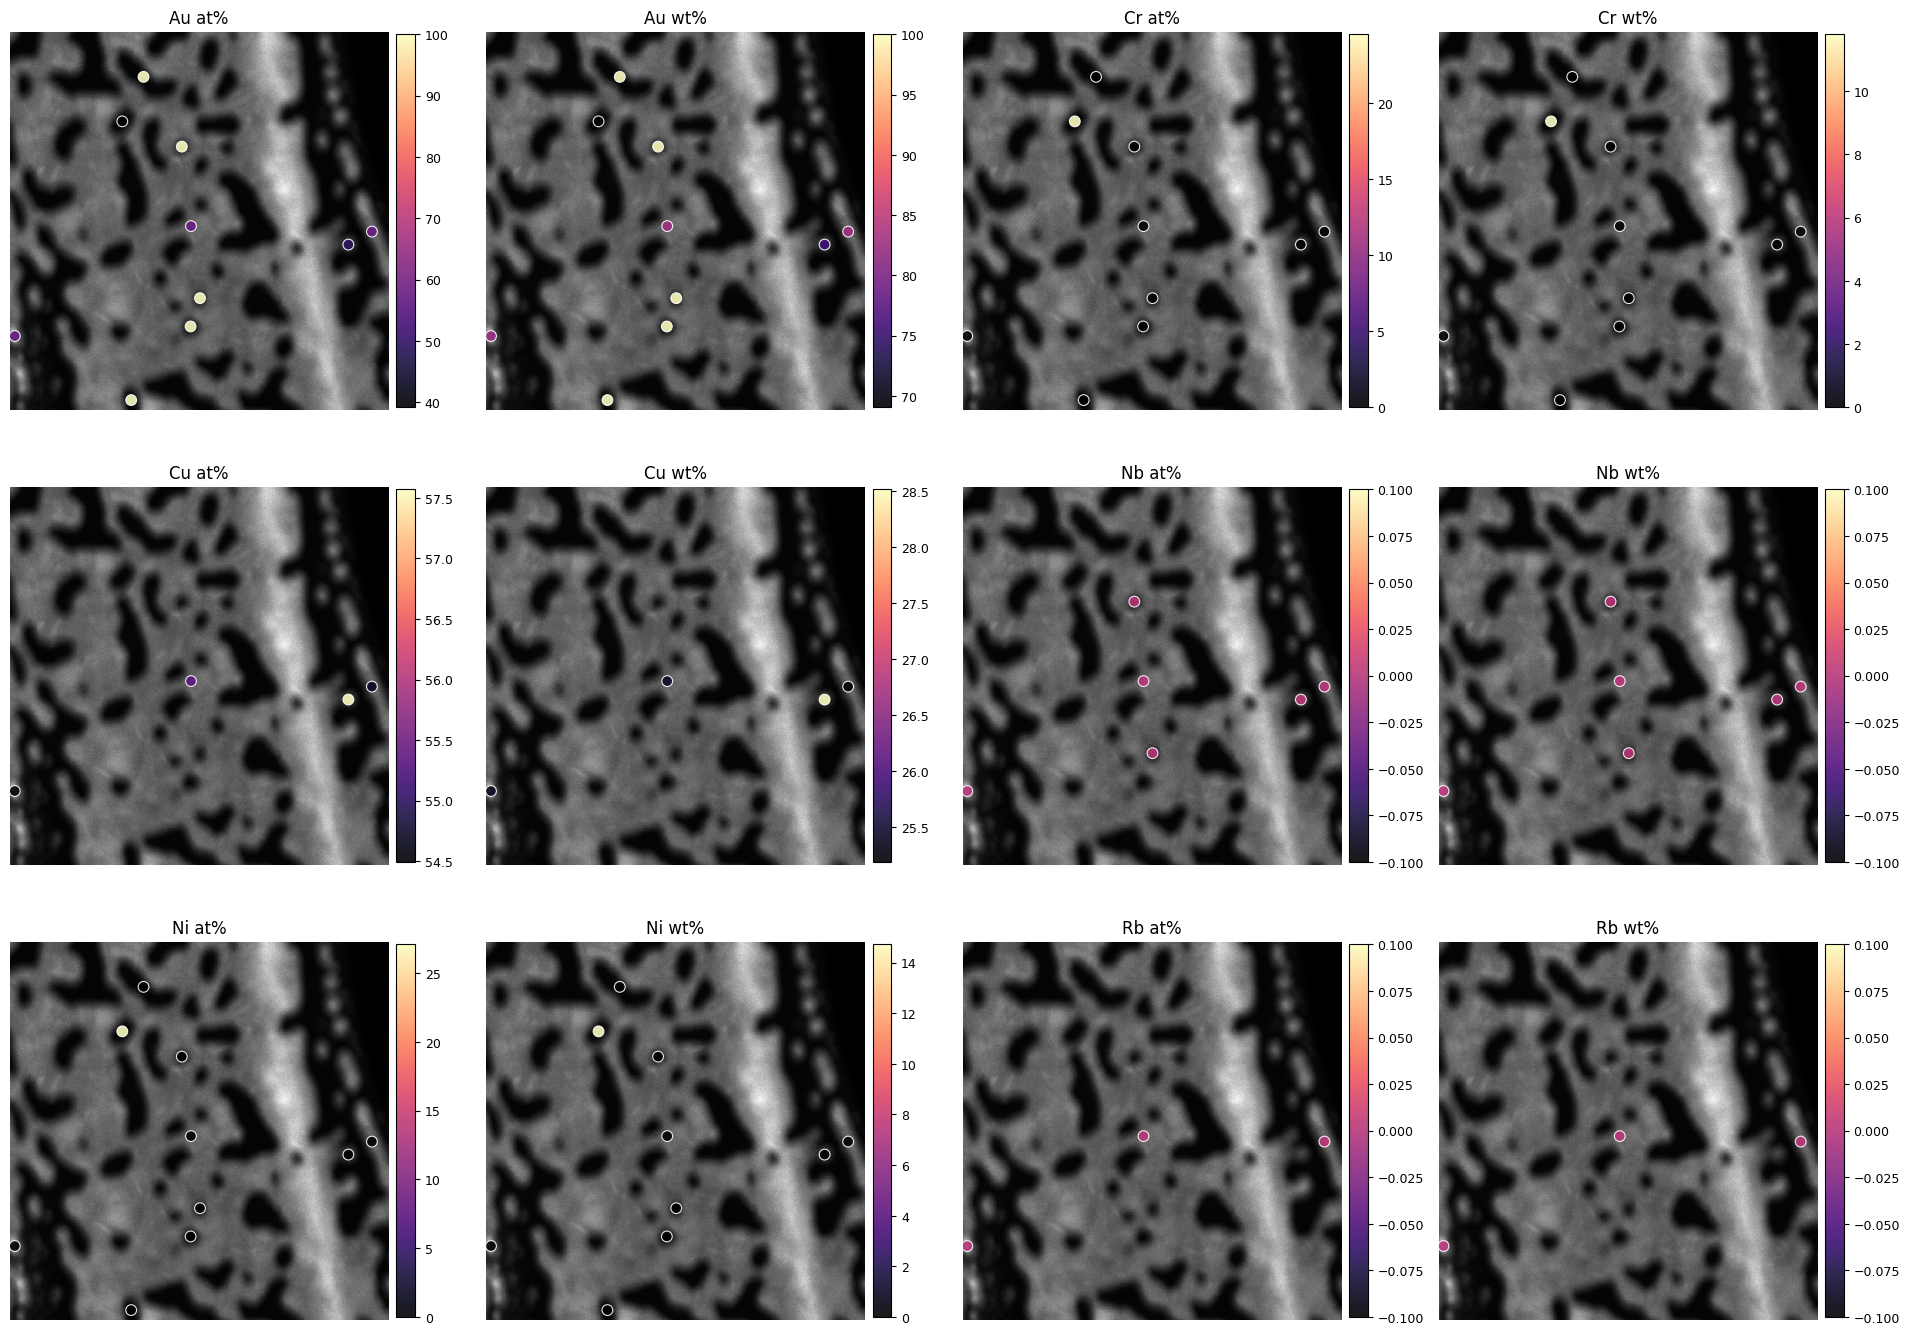

In [63]:
plot_edx_overlays_pretty(
    haadf=haadf,
    centroid_pixel_pos=pixel_pos[:10],
    results_list=results_list,
    metrics=("at%", "wt%"),
    n_cols=4,
)